# Análisis FBG: 4 + 4 Sensores - Fibra DW-3 Ormocer-T en el canal 2 y Poliamida POLY-1 en el canal 1 del interrogador (26/02/2026)

# Solo datos de picos y de espectros para caracterizar un espectro de fibra de poliamida

# para entender el interrogador y convert spectrum

## 1️⃣ Importar Librerías

In [1]:
# Reiniciar kernel si hay problemas con imports
import sys
print(f"Python ejecutable: {sys.executable}")
print(f"Python versión: {sys.version}")

# Verificar que scipy está disponible
try:
    import scipy
    print("✅ scipy disponible")
except ImportError:
    print("❌ scipy no encontrado - instalando...")
    import subprocess
    subprocess.check_call([sys.executable, "-m", "pip", "install", "scipy"])
    print("✅ scipy instalado - reinicia el kernel")

Python ejecutable: /usr/bin/python3.11
Python versión: 3.11.13 (main, Jan 16 2026, 00:00:00) [GCC 11.5.0 20240719 (Red Hat 11.5.0-11)]
✅ scipy disponible


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import datetime
from scipy import stats
import uproot

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


## 2️⃣ Cargar Datos del Archivo ROOT

In [3]:
# 🔧 CONFIGURA AQUÍ LA RUTA DE TU ARCHIVO
# Archivo de datos para la fibra de poliamida POLY-1
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"

# ⚙️ CONFIGURAR TIME_SHIFT (corrección temporal para wavelength)
# Los picos tienen un desfase de +2h respecto a temperatura
TIME_SHIFT = datetime.timedelta(hours=2)  # ✅ Shift confirmado para este dataset

print(f"📂 Cargando archivo ROOT para fibra POLY-1: {filepath}")
print(f"⏱️  TIME_SHIFT configurado: {TIME_SHIFT.total_seconds()/3600:.1f} horas")

# Verificar que el archivo existe
import os
if not os.path.exists(filepath):
    print(f"❌ ERROR: Archivo no encontrado: {filepath}")
    raise FileNotFoundError(f"El archivo {filepath} no existe")

# Verificar tamaño del archivo
file_size = os.path.getsize(filepath)
print(f"📊 Tamaño del archivo: {file_size / (1024**2):.2f} MB")

if file_size < 1000:  # Menos de 1 KB es sospechoso
    print(f"⚠️  ADVERTENCIA: El archivo parece muy pequeño ({file_size} bytes)")
    print(f"   Puede estar corrupto o vacío")

# Cargar datos del archivo ROOT
try:
    print("\n🔄 Abriendo archivo ROOT...")
    file = uproot.open(filepath)
    print("✅ Archivo ROOT abierto correctamente")
    
    # Mostrar estructura del archivo
    print("\n📋 Estructura del archivo ROOT:")
    print(f"   Keys disponibles: {file.keys()}")
    
    # Cargar TTrees por nombre correcto
    print(f"\n🌳 Cargando TTrees individuales...")
    
    # Cargar cada TTree por separado
    tree_peak = file["peak;2"]
    # Cargar espectros si existen
    if "spectrum;4" in file.keys():
        tree_spectrum = file["spectrum;4"]
        print(f"   ✅ TTree 'spectrum;4' cargado: {tree_spectrum.num_entries} entradas")
        print(f"   Branches en 'spectrum;4': {tree_spectrum.keys()}")
    else:
        tree_spectrum = None
        print(f"   ⚠️  TTree 'spectrum;4' no encontrado en el archivo ROOT")
    
    print(f"   ✅ TTree 'peak;2' cargado: {tree_peak.num_entries} entradas")
    
    print(f"\n   Branches en 'peak;2': {tree_peak.keys()}")
    
    # Extraer datos en arrays de NumPy
    print("\n📦 Extrayendo datos a arrays NumPy...")
    data_peak = tree_peak.arrays(library="np")
    if tree_spectrum is not None:
        data_spectrum = tree_spectrum.arrays(library="np")
        print(f"   ✅ Datos de espectros extraídos: {len(data_spectrum)} branches")
        print(f"   Keys espectros: {list(data_spectrum.keys())}")
    else:
        data_spectrum = None
    
    # Combinar en un solo diccionario para compatibilidad con el resto del código
    data = {}
    
    # Agregar datos de wavelength (picos)
    for key in data_peak.keys():
        data[key] = data_peak[key]
    
    # Agregar datos de espectros si existen
    if data_spectrum is not None:
        # Si existen branches 'wav' y 't', agregarlos como 'spectrum_wav' y 'spectrum_t'
        if 'wav' in data_spectrum and 't' in data_spectrum:
            data['spectrum_wav'] = data_spectrum['wav']
            data['spectrum_t'] = data_spectrum['t']
        # Agregar todos los branches de espectro con prefijo 'spectrum_'
        for key in data_spectrum.keys():
            data[f"spectrum_{key}"] = data_spectrum[key]
    
    print(f"\n✅ Datos extraídos y combinados correctamente")
    print(f"   Total de branches: {len(data.keys())}")
    print(f"   Keys disponibles: {list(data.keys())}")

except FileNotFoundError:
    print(f"\n❌ ERROR CRÍTICO: No se puede acceder al archivo")
    print(f"   Ruta: {filepath}")
    print(f"   Verifica que:")
    print(f"   1. Estás ejecutando desde lxplus")
    print(f"   2. El archivo existe en /eos/")
    print(f"   3. Tienes permisos de lectura")
    raise
except Exception as e:
    print(f"\n❌ ERROR al cargar datos: {e}")
    print(f"   Tipo de error: {type(e).__name__}")
    import traceback
    traceback.print_exc()
    raise

# Verificar que tenemos los datos esperados
print(f"\n🔍 Verificando datos cargados...")
print(f"   Keys totales: {len(data.keys())}")
print(f"   Keys disponibles: {list(data.keys())}")


📂 Cargando archivo ROOT para fibra POLY-1: /eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root
⏱️  TIME_SHIFT configurado: 2.0 horas
📊 Tamaño del archivo: 84.89 MB

🔄 Abriendo archivo ROOT...
✅ Archivo ROOT abierto correctamente

📋 Estructura del archivo ROOT:
   Keys disponibles: ['peak;2', 'spectrum;4']

🌳 Cargando TTrees individuales...
   ✅ TTree 'spectrum;4' cargado: 571 entradas
   Branches en 'spectrum;4': ['t', 'wav']
   ✅ TTree 'peak;2' cargado: 142750 entradas

   Branches en 'peak;2': ['t', 'wav', 'sweep', 'ch', 'pos']

📦 Extrayendo datos a arrays NumPy...
   ✅ Datos de espectros extraídos: 2 branches
   Keys espectros: ['t', 'wav']

✅ Datos extraídos y combinados correctamente
   Total de branches: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']

🔍 Verificando datos cargados...
   Keys totales: 7
   Keys disponibles: ['t', 'wav', 'sweep', 'ch', 'pos', 'spectrum_wav', 'spectrum_t']


## 3️⃣ Filtrar Rango Temporal

In [4]:
# 📊 Número de sensores FBG a analizar
num_sensores = 8  # Este experimento tiene 4 + 4 sensores FBG

# Extraer wavelengths y calcular media de polarizaciones
# Estructura de wav: (n_medidas, 2_polarizaciones, 5_sensores)
wav_raw = data_peak["wav"]

# wav_raw ya tiene forma (n_medidas, 2, num_sensores)
# Necesitamos reordenarlo a (n_medidas, num_sensores, 2) para media
wav_reshaped = np.transpose(wav_raw, (0, 2, 1))  # (n_medidas, num_sensores, 2_pol)

# Calcular media entre polarizaciones para cada sensor
wav_mean = np.mean(wav_reshaped, axis=2)  # (n_medidas, num_sensores)

# Extraer arrays de temperatura (8 RTDs)
#temp_raw = data_temp["temp"]

# Crear array de tiempos wavelength (ya con shift aplicado) para compatibilidad
# Buscar el branch correcto para los tiempos de wavelength
if 't' in data_peak:
    time_wavelength_shifted = data_peak['t']
elif 'timestamps' in data:
    time_wavelength_shifted = data['timestamps']
else:
    raise NameError("No se encontró el branch de tiempo para wavelength (ni 't' ni 'timestamps')")
times_all = time_wavelength_shifted

# Crear array de tiempos temperatura (sin shift)
#times_temp = time_temp

# Crear array de tiempos presión (sin shift)
#times_press = time_press

# Datos de presión
#press_raw = data_press["press"]

# press_raw tiene forma (n_medidas, 1) - extraer primera columna
#if len(press_raw.shape) > 1:
    #press_data_plot = press_raw[:, 0]
#else:
    #press_data_plot = press_raw
    
#print(f"✅ Datos de presión cargados: {len(press_data_plot):,} puntos")

print(f"\n📊 Resumen de datos cargados:")
print(f"   Wavelength (media pol): {wav_mean.shape} = {wav_mean.shape[0]:,} medidas × {num_sensores} sensores")
#print(f"   Temperatura: {temp_raw.shape} = {temp_raw.shape[0]:,} medidas × 8 RTDs")
#print(f"   Presión: {len(press_data_plot):,} medidas")
print(f"   Timestamps wavelength: {len(times_all):,}")
#print(f"   Timestamps temperatura: {len(times_temp):,}")
#print(f"   Timestamps presión: {len(times_press):,}")

# ============================================================================
# ⬅️ AJUSTA AQUÍ EL RANGO TEMPORAL QUE QUIERES ANALIZAR
# ============================================================================
use_full_range = True  # Cambiar a False para rango específico

if use_full_range:
    t_inicio = times_all[0]
    t_fin = times_all[-1]
else:
    fecha = datetime.date(2026, 3, 2)
    t_inicio = datetime.datetime.combine(fecha, datetime.time(9, 50))
    t_fin = datetime.datetime.combine(fecha, datetime.time(11, 5))

# Filtrar wavelength (tiene TIME_SHIFT aplicado)
mask_time = (times_all >= t_inicio) & (times_all <= t_fin)
times_filtered = times_all[mask_time]
wav_filtered = wav_raw[mask_time]

# Filtrar presión
#mask_time_press = (times_press >= t_inicio) & (times_press <= t_fin)
#press_filtered = press_data_plot[mask_time_press]
#times_press_filtered = times_press[mask_time_press]

# Imprimir rango seleccionado con conversión segura a string
def safe_strftime(dt, fmt):
    import datetime
    if isinstance(dt, datetime.datetime):
        return dt.strftime(fmt)
    elif hasattr(dt, 'astype'):
        try:
            dt_obj = dt.astype('datetime64[s]').astype(datetime.datetime)
            return dt_obj.strftime(fmt)
        except Exception:
            return str(dt)
    else:
        return str(dt)

print(f"\n✅ Rango seleccionado: {safe_strftime(t_inicio, '%Y-%m-%d %H:%M')} - {safe_strftime(t_fin, '%H:%M')}")
print(f"   Puntos wavelength: {len(times_filtered):,}")
#print(f"   Puntos temperatura: {len(times_temp_filtered):,}")
#print(f"   Puntos presión: {len(times_press_filtered):,}")
if len(times_filtered) == 0:
    print(f"\n⚠️  Sin datos en el rango. Activa 'use_full_range = True' o ajusta t_inicio/t_fin.")


📊 Resumen de datos cargados:
   Wavelength (media pol): (142750, 8) = 142,750 medidas × 8 sensores
   Timestamps wavelength: 142,750

✅ Rango seleccionado: [1.77243787e+09 1.77243787e+09] - [1.77243901e+09 1.77243901e+09]
   Puntos wavelength: 285,500


## 5️⃣ Procesamiento FBG: Filtrado y Media de Polarizaciones

### 5.1 Configuración de 4 Sensores FBG

In [5]:
# ✅ CONFIGURACIÓN: 8 sensores FBG completos (4 + 4)
# 8 sensores × 2 polarizaciones = 16 canales
# Índices 0-based: sensor 0, 1, 2, 3, 4, 5, 6, 7 (Python indexing)
fbg_config = []
for sensor in range(8):
    fbg_config.append({"pol": 0, "sensor": sensor, "label": f"FBG-{sensor+1}-P"})
    fbg_config.append({"pol": 1, "sensor": sensor, "label": f"FBG-{sensor+1}-S"})
print(f"✅ Configurados {len(fbg_config)} canales FBG (8 sensores × 2 polarizaciones)")
print(f"💡 Se verificará si hay datos válidos para todos los sensores en este dataset")

✅ Configurados 16 canales FBG (8 sensores × 2 polarizaciones)
💡 Se verificará si hay datos válidos para todos los sensores en este dataset


### 5.2 Filtrado Wavelength (μ±3σ)

In [6]:
def filter_wavelength_data(wav_data, timestamps, sigma_threshold=3.0, use_robust=True):
    """
    Filtra wavelength usando método μ±3σ o método robusto basado en mediana (MAD)
    
    Parameters:
    -----------
    wav_data : array
        Datos de wavelength a filtrar
    timestamps : array
        Timestamps correspondientes
    sigma_threshold : float
        Número de sigmas (o MADs) para el threshold
    use_robust : bool
        Si True, usa MAD (Median Absolute Deviation) en lugar de std
    """
    mask_positive = wav_data > 0
    wav_positive = wav_data[mask_positive]
    
    # Si no hay datos válidos, retornar estructura vacía
    if len(wav_positive) == 0:
        return {
            "timestamps": np.array([]),
            "wavelength": np.array([]),
            "mean": np.nan,
            "std": np.nan,
            "n_valid": 0
        }
    
    if use_robust:
        # Método robusto: usa MEDIANA y MAD (más resistente a outliers)
        median_wav = np.median(wav_positive)
        mad = np.median(np.abs(wav_positive - median_wav))
        # Convertir MAD a escala comparable con std (factor 1.4826)
        sigma_equiv = 1.4826 * mad
        
        threshold_min = median_wav - sigma_threshold * sigma_equiv
        threshold_max = median_wav + sigma_threshold * sigma_equiv
        
        # Filtrar usando los thresholds robustos
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
        
        # Calcular estadísticas finales sobre datos filtrados
        wav_filtered = wav_data[mask_filtered]
        mean_wav = np.mean(wav_filtered)
        std_wav = np.std(wav_filtered)
    else:
        # Método clásico: μ±3σ
        mean_wav = np.mean(wav_positive)
        std_wav = np.std(wav_positive)
        threshold_min = mean_wav - sigma_threshold * std_wav
        threshold_max = mean_wav + sigma_threshold * std_wav
        
        mask_filtered = (wav_data > 0) & (wav_data >= threshold_min) & (wav_data <= threshold_max)
    
    return {
        "timestamps": timestamps[mask_filtered],
        "wavelength": wav_data[mask_filtered],
        "mean": mean_wav,
        "std": std_wav,
        "n_valid": np.sum(mask_filtered)
    }
    
    # DIAGNÓSTICO: Verificar forma y valores de los sensores
    print(f"🔍 Forma de wav_filtered: {wav_filtered.shape}")
    print(f"   Dimensiones: (time={wav_filtered.shape[0]}, pol={wav_filtered.shape[1]}, sensor={wav_filtered.shape[2]})")
    print(f"\n🔍 Diagnóstico de valores por sensor (FBG-1 a FBG-8):")
    for sensor_idx in range(8):
        for pol_idx in range(2):
            pol_name = "P" if pol_idx == 0 else "S"
            sensor_data = wav_filtered[:, pol_idx, sensor_idx]
            n_positive = np.sum(sensor_data > 0)
            if n_positive > 0:
                min_val = np.min(sensor_data[sensor_data > 0])
                max_val = np.max(sensor_data)
                mean_val = np.mean(sensor_data[sensor_data > 0])
            else:
                min_val = max_val = mean_val = 0
            print(f"   FBG-{sensor_idx+1}-{pol_name}: {n_positive:7d} pts > 0, range=[{min_val:.2e}, {max_val:.2e}] nm, μ={mean_val:.2e} nm")

### 5.3 Calcular Media de Polarizaciones

In [7]:
# Filtrar datos wavelength para cada sensor y polarización (8 sensores × 2 pol)
# Diagnóstico de shapes y tipos
print(f"wav_raw shape: {wav_raw.shape}")
print(f"times_all shape: {times_all.shape}")
print(f"times_all[0]: {times_all[0]}")

# Usar solo la primera columna de times_all para el tiempo de wavelength (P)
times_wav = times_all[:, 0]  # shape (153125,)
print(f"times_wav shape: {times_wav.shape}, dtype: {times_wav.dtype}, first: {times_wav[0]}")

# Definir t_inicio y t_fin como escalares para la columna usada
t_inicio = times_all[0, 0]
t_fin = times_all[-1, 0]
print(f"t_inicio: {t_inicio}, t_fin: {t_fin}, type: {type(t_inicio)}")

# Si times_wav es float (timestamp), no convertir
times_wav_dt = times_wav

# Crear máscara temporal
mask_time = (times_wav_dt >= t_inicio) & (times_wav_dt <= t_fin)
print(f"mask_time shape: {mask_time.shape}, sum: {np.sum(mask_time)}")

fbg_filtered_data = {}
for config in fbg_config:
    pol = config['pol']
    sensor = config['sensor']
    label = config['label']
    wav_sensor_pol = wav_raw[:, pol, sensor][mask_time]
    timestamps_sensor = times_wav_dt[mask_time]
    filtered = filter_wavelength_data(wav_sensor_pol, timestamps_sensor, sigma_threshold=3.0, use_robust=True)
    fbg_filtered_data[label] = filtered
print(f"✅ Datos filtrados para {len(fbg_filtered_data)} canales (8 sensores × 2 pol)")

wav_raw shape: (142750, 2, 8)
times_all shape: (142750, 2)
times_all[0]: [1.77243787e+09 1.77243787e+09]
times_wav shape: (142750,), dtype: float64, first: 1772437866.701463
t_inicio: 1772437866.701463, t_fin: 1772439008.694874, type: <class 'numpy.float64'>
mask_time shape: (142750,), sum: 142750
✅ Datos filtrados para 16 canales (8 sensores × 2 pol)


In [8]:
# Calcular media P+S para cada sensor (8 sensores: 1 a 8)
fbg_mean_data = {}

for sensor_num in range(1, 9):  # Sensores 1 a 8
    label_p = f"FBG-{sensor_num}-P"
    label_s = f"FBG-{sensor_num}-S"
    label_mean = f"FBG-{sensor_num}-Mean"
    data_p = fbg_filtered_data[label_p]
    data_s = fbg_filtered_data[label_s]
    times_p = data_p["timestamps"]
    times_s = data_s["timestamps"]
    wav_p = data_p["wavelength"]
    wav_s = data_s["wavelength"]
    # Verificar que hay datos válidos
    if len(times_p) == 0 or len(times_s) == 0:
        print(f"⚠️ FBG-{sensor_num} no tiene datos suficientes, omitiendo...")
        continue
    # Interpolar S a tiempos de P (usar directamente los float timestamps)
    times_p_sec = np.array(times_p)
    times_s_sec = np.array(times_s)
    wav_s_interp = np.interp(times_p_sec, times_s_sec, wav_s)
    # Media
    wav_mean = (wav_p + wav_s_interp) / 2.0
    fbg_mean_data[label_mean] = {
        "timestamps": times_p,
        "wavelength": wav_mean,
        "mean": np.mean(wav_mean),
        "std": np.std(wav_mean),
        "n_valid": len(wav_mean),
        "sensor_num": sensor_num
    }

print("✅ Medias calculadas (P+S)/2 para todos los sensores")
print(f"\n{'Sensor':<15} {'Mean (nm)':<15} {'Std (nm)':<15} {'N puntos'}")
print("="*65)
for label, data in fbg_mean_data.items():
    print(f"{label:<15} {data['mean']:<15.6e} {data['std']:<15.6e} {data['n_valid']}")

✅ Medias calculadas (P+S)/2 para todos los sensores

Sensor          Mean (nm)       Std (nm)        N puntos
FBG-1-Mean      1.545073e-06    2.510868e-12    142750
FBG-2-Mean      1.550922e-06    4.648183e-13    141800
FBG-3-Mean      1.556464e-06    1.192908e-11    141923
FBG-4-Mean      1.560772e-06    2.385462e-12    133048
FBG-5-Mean      1.545045e-06    1.214569e-12    142750
FBG-6-Mean      1.550765e-06    3.638103e-13    142750
FBG-7-Mean      1.556542e-06    3.262838e-13    142750
FBG-8-Mean      1.562361e-06    2.820250e-13    142711


### 5.4 Visualizar Wavelengths (Media de Polarizaciones)

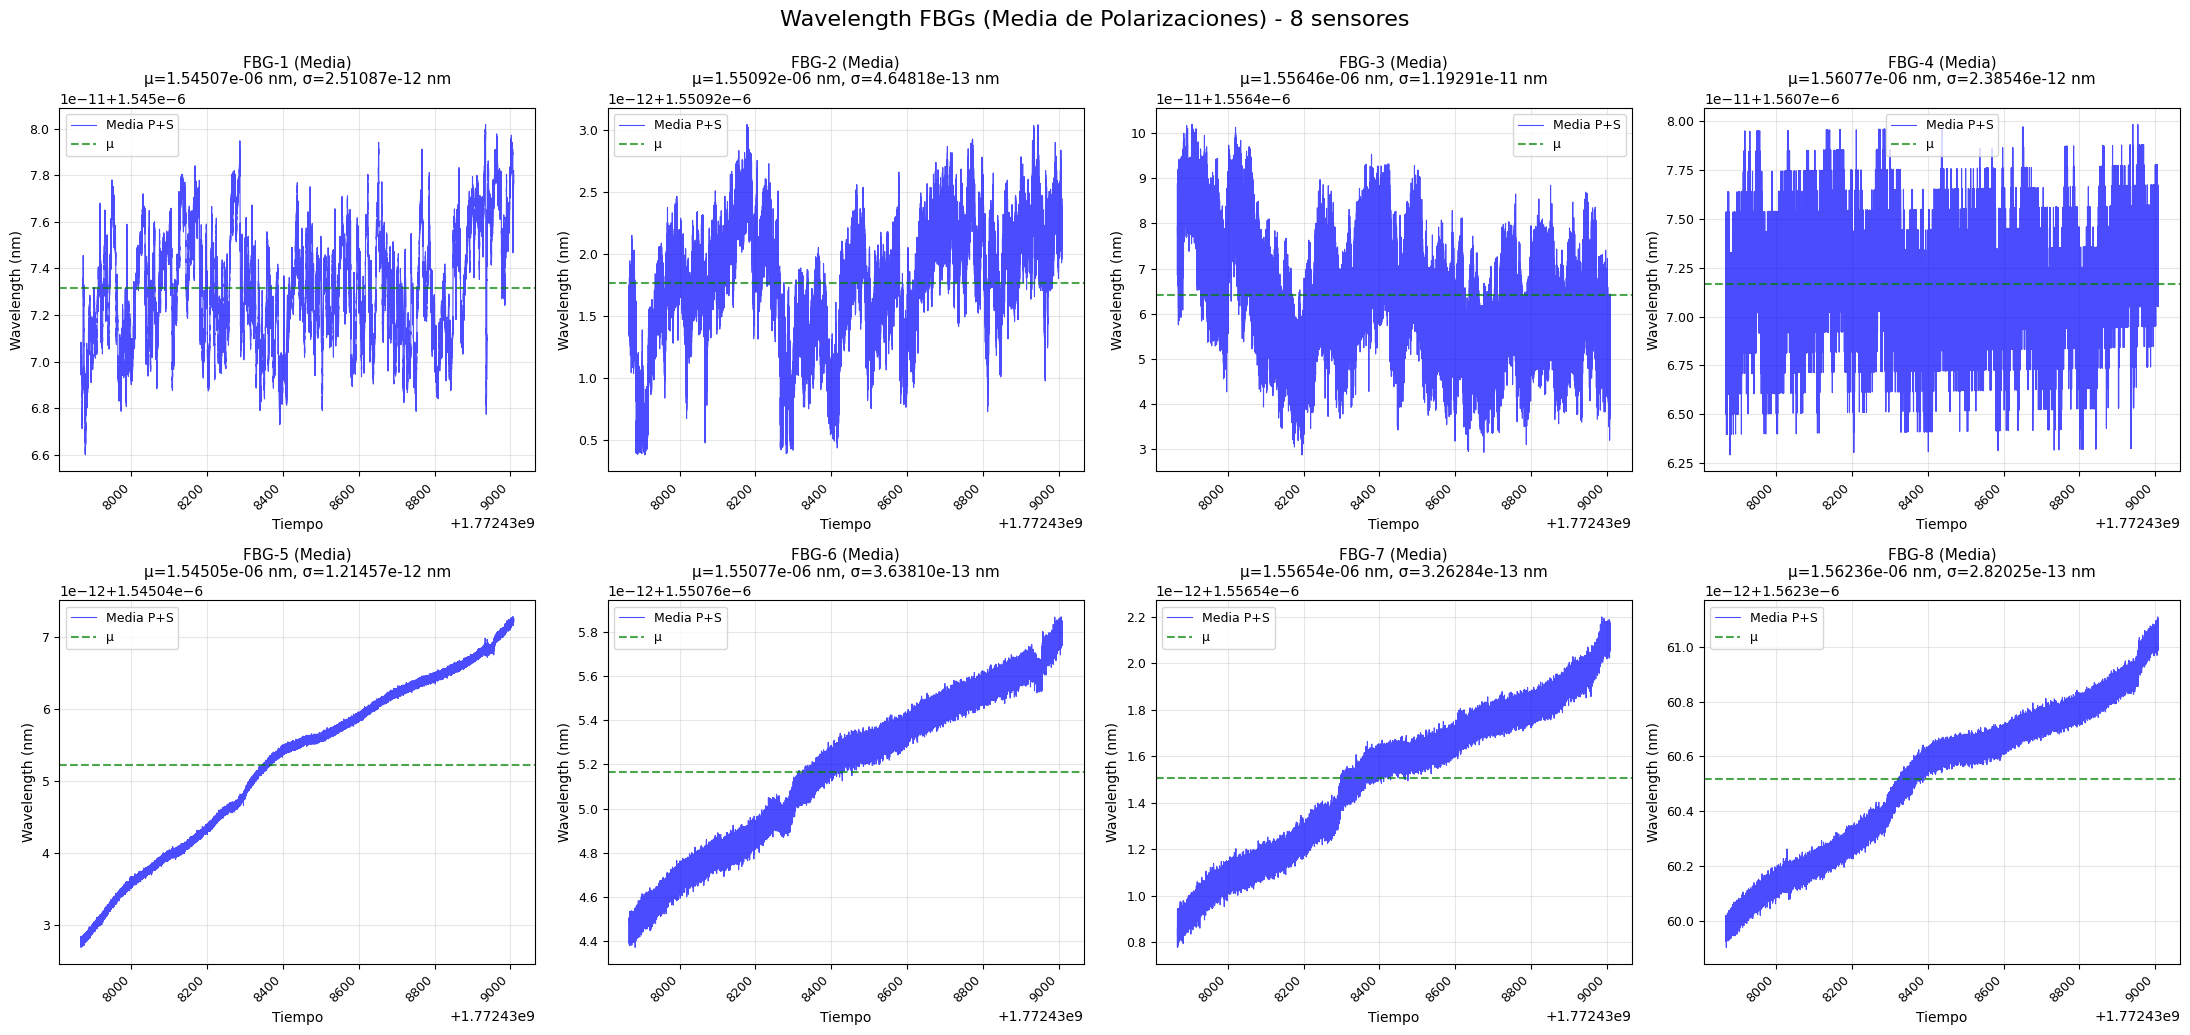

💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales


In [9]:
# Visualizar Wavelengths (Media de Polarizaciones) para 8 sensores
n_sensors = len(fbg_mean_data)
fig, axes = plt.subplots(2, 4, figsize=(22, 10))
axes = axes.flatten()

for idx, (label, data) in enumerate(fbg_mean_data.items()):
    times_fbg = data["timestamps"]
    wav_fbg = data["wavelength"]
    sensor_num = data["sensor_num"]
    axes[idx].plot(times_fbg, wav_fbg, 'b-', linewidth=0.8, alpha=0.7, label='Media P+S')
    axes[idx].axhline(data['mean'], color='g', linestyle='--', linewidth=1.5, alpha=0.7, label='μ')
    # Añadir líneas verticales de plateaus (si están definidos)
    if 'plateau_data' in globals() and len(plateau_data) > 0:
        for plateau in plateau_data:
            axes[idx].axvline(plateau["t0"], color='red', linestyle='--', linewidth=1.2, alpha=0.5)
            axes[idx].axvline(plateau["tfin"], color='blue', linestyle='--', linewidth=1.2, alpha=0.5)
    axes[idx].set_title(f"FBG-{sensor_num} (Media)\nμ={data['mean']:.5e} nm, σ={data['std']:.5e} nm", fontsize=11)
    axes[idx].set_xlabel('Tiempo', fontsize=10)
    axes[idx].set_ylabel('Wavelength (nm)', fontsize=10)
    axes[idx].grid(True, alpha=0.3)
    axes[idx].legend(fontsize=9)
    axes[idx].tick_params(labelsize=9)
    for tick_label in axes[idx].get_xticklabels():
        tick_label.set_rotation(45)
        tick_label.set_ha('right')

plt.tight_layout()
plt.suptitle(f'Wavelength FBGs (Media de Polarizaciones) - {n_sensors} sensores', fontsize=16, y=1.03)
plt.show()

if 'plateau_data' in globals() and len(plateau_data) > 0:
    print(f"🔴🔵 Plateaus marcados con líneas verticales (rojo=inicio, azul=fin)")
else:
    print(f"💡 Ejecuta primero la celda 6.3 (definición de plateaus) para ver las líneas verticales")

spectrum_wav shape: (571, 2, 3, 39200)


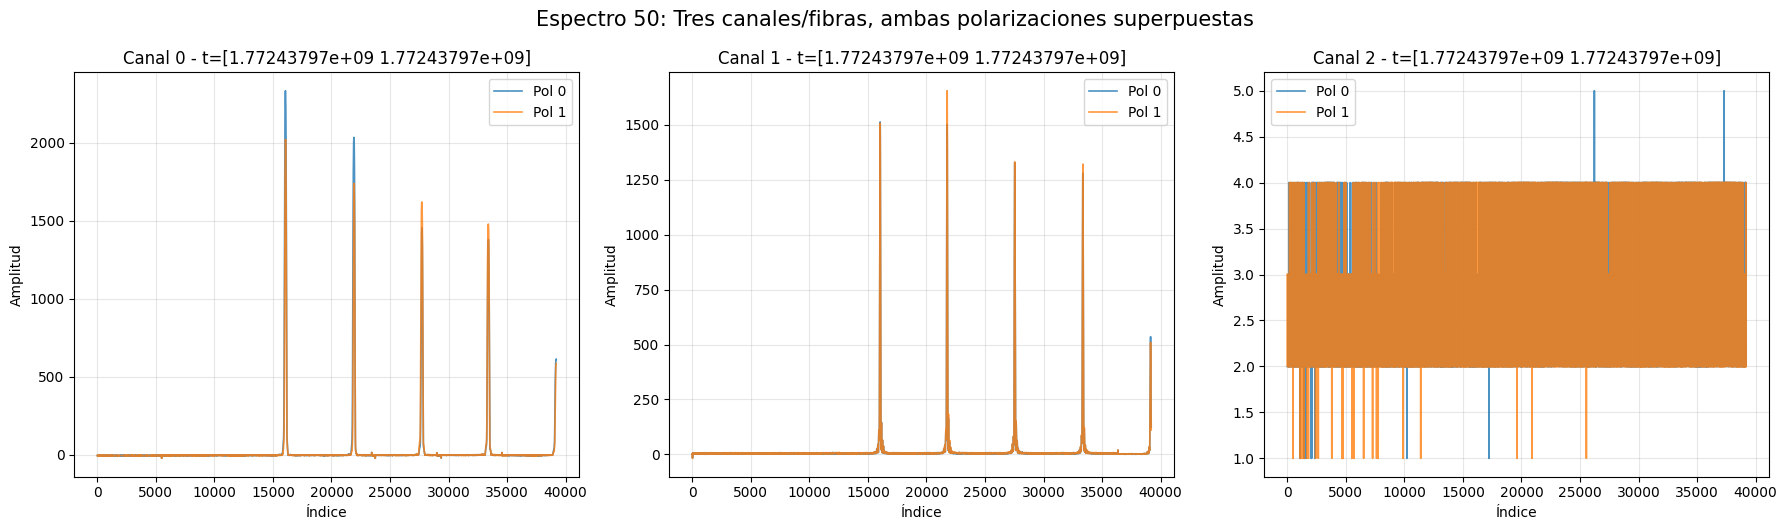

In [14]:
# Plotear espectro completo para canales 0, 1 y 2, ambas polarizaciones superpuestas
import uproot
import matplotlib.pyplot as plt
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"
file = uproot.open(filepath)
tree_spectrum = file["spectrum;4"]
data_spectrum = tree_spectrum.arrays(library="np")
spectrum_wav = data_spectrum['wav']  # shape: (n_espectros, n_pol, n_chan, n_puntos)
spectrum_t = data_spectrum['t']      # shape: (n_espectros,)
shape = spectrum_wav.shape
print(f"spectrum_wav shape: {shape}")
if len(shape) == 4:
    n_espectros, n_pol, n_chan, n_puntos = shape
    idx_espectro = 50  # Primer espectro
    canales_a_mostrar = [0, 1, 2]
    pol_labels = ['Pol 0', 'Pol 1']
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    for i, idx_chan in enumerate(canales_a_mostrar):
        ax = axes[i]
        for idx_pol in range(n_pol):
            wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
            ax.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
        t = spectrum_t[idx_espectro]
        ax.set_title(f'Canal {idx_chan} - t={t}')
        ax.set_xlabel('Índice')
        ax.set_ylabel('Amplitud')
        ax.grid(True, alpha=0.3)
        ax.legend()
    plt.tight_layout()
    plt.suptitle(f'Espectro {idx_espectro}: Tres canales/fibras, ambas polarizaciones superpuestas', fontsize=15, y=1.05)
    plt.show()
else:
    print("Estructura inesperada en spectrum_wav. Esperado 4D (espectro, pol, canal, puntos).")

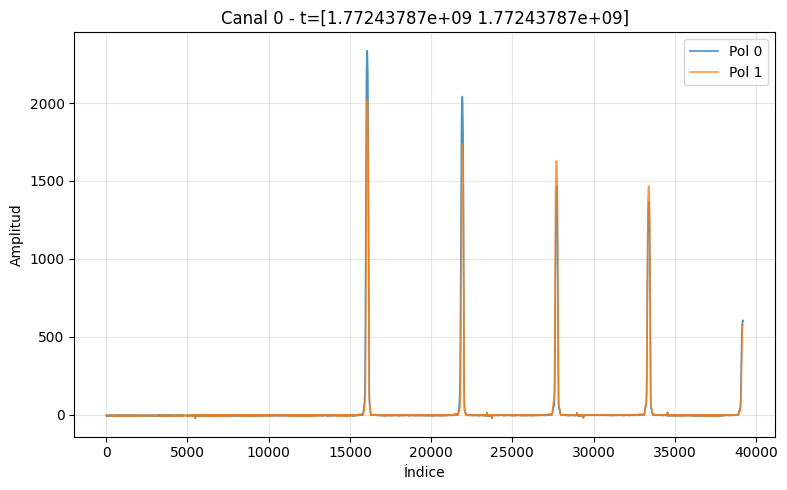

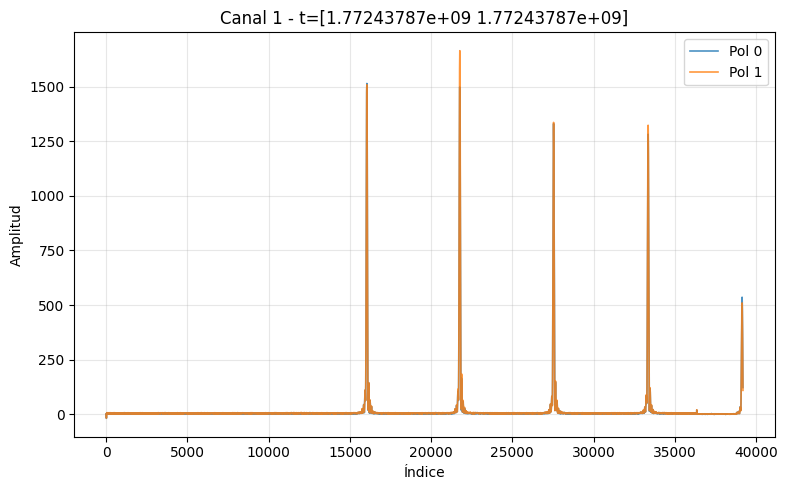

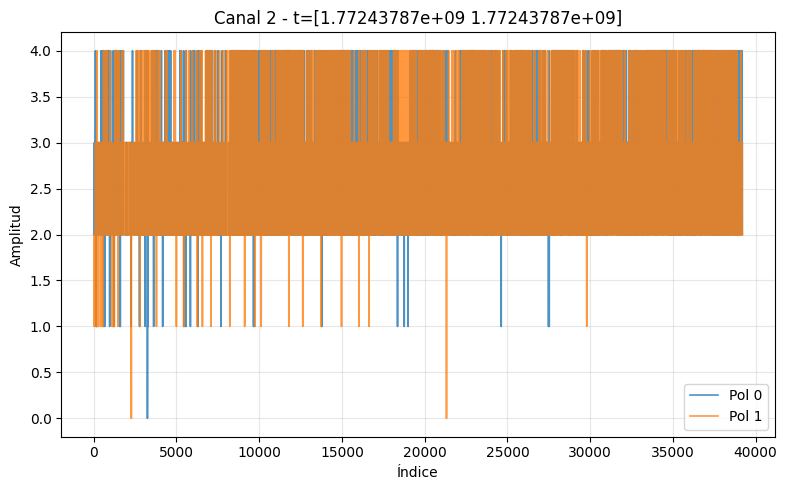

In [13]:
# Espectro canal 0 (ambas polarizaciones)
import uproot
import matplotlib.pyplot as plt
filepath = "/eos/user/j/jcapotor/FBGdata/ROOTFiles/pressure_setup/20260302.root"
file = uproot.open(filepath)
tree_spectrum = file["spectrum;4"]
data_spectrum = tree_spectrum.arrays(library="np")
spectrum_wav = data_spectrum['wav']
spectrum_t = data_spectrum['t']
shape = spectrum_wav.shape
idx_espectro = 0
idx_chan = 0
n_pol = shape[1]
pol_labels = ['Pol 0', 'Pol 1']
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Espectro canal 1 (ambas polarizaciones)
idx_chan = 1
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()
# Espectro canal 2 (ambas polarizaciones)
idx_chan = 2
plt.figure(figsize=(8, 5))
for idx_pol in range(n_pol):
    wav = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
    plt.plot(wav, label=pol_labels[idx_pol], linewidth=1.2, alpha=0.8)
t = spectrum_t[idx_espectro]
plt.title(f'Canal {idx_chan} - t={t}')
plt.xlabel('Índice')
plt.ylabel('Amplitud')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

POLY-1 Pol 0: peak idx=16066, FWHM=177.67 pts
POLY-1 Pol 1: peak idx=16078, FWHM=153.45 pts
DW-3 Pol 0: peak idx=16044, FWHM=76.80 pts
DW-3 Pol 1: peak idx=16042, FWHM=76.77 pts


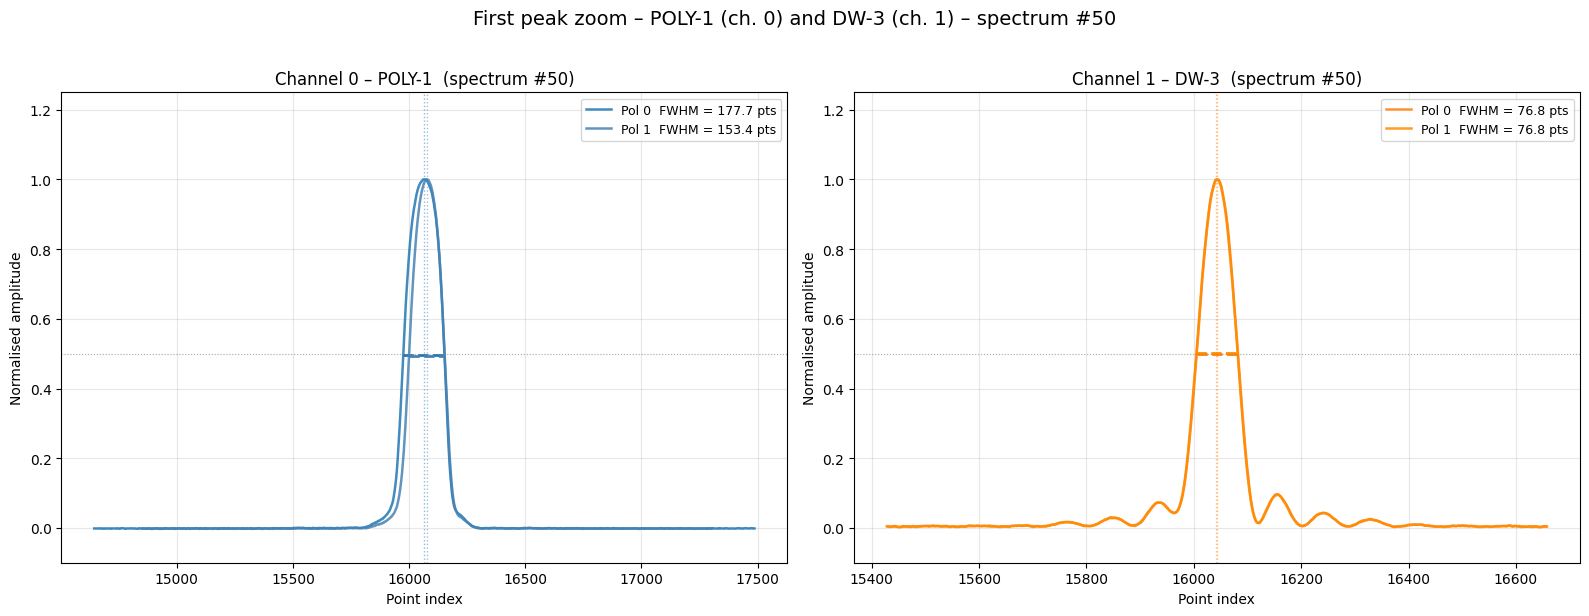

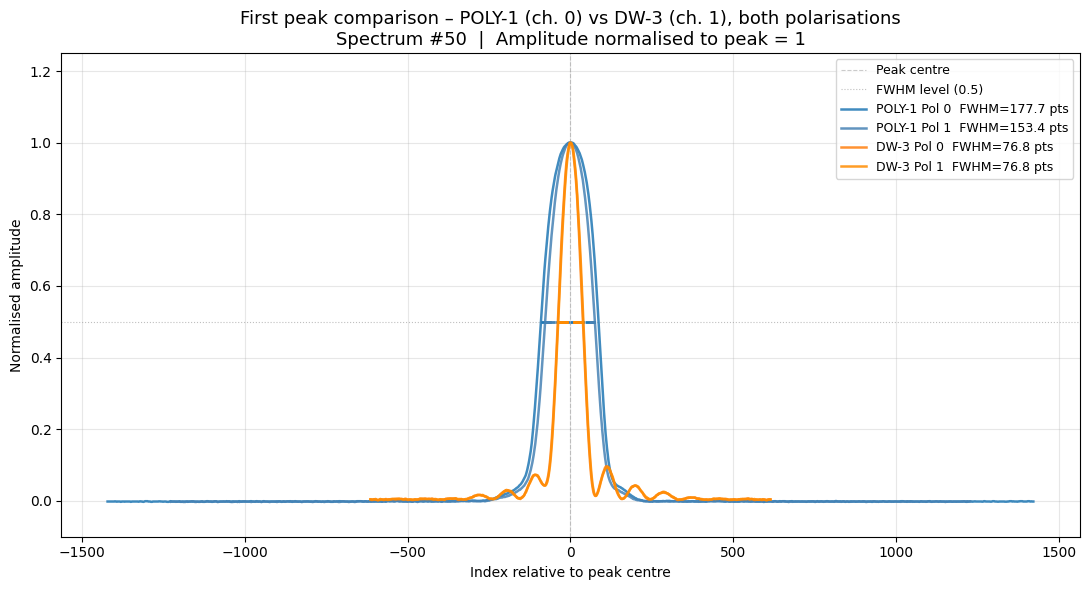

In [16]:
from scipy.signal import find_peaks, peak_widths
import matplotlib.pyplot as plt
import numpy as np

# ──────────────────────────────────────────────────────────
# Configuration
# ──────────────────────────────────────────────────────────
idx_espectro = 50          # Spectrum index to analyse
channel_info = {0: 'POLY-1', 1: 'DW-3'}   # ch 0 and ch 1 only
pol_labels   = ['Pol 0', 'Pol 1']
colors_chan  = {0: ['tab:blue',   'steelblue'],
                1: ['tab:orange', 'darkorange']}

# ──────────────────────────────────────────────────────────
# Helper: find first *real* peak above noise floor + FWHM
# Uses height > 5 % of max to skip noise bumps at array edges
# ──────────────────────────────────────────────────────────
def get_first_peak(signal, min_prominence_factor=0.10, min_distance=10, min_height_factor=0.05):
    """Return (peak_idx, fwhm, width_height, left_ip, right_ip) for the first real peak."""
    sig_max    = np.max(signal)
    height     = sig_max * min_height_factor
    prominence = sig_max * min_prominence_factor
    peaks, _   = find_peaks(signal, prominence=prominence, distance=min_distance, height=height)
    if len(peaks) == 0:
        return None
    first = peaks[0]
    widths, w_heights, left_ips, right_ips = peak_widths(signal, [first], rel_height=0.5)
    return first, widths[0], w_heights[0], left_ips[0], right_ips[0]

# ──────────────────────────────────────────────────────────
# PLOT 1: zoomed first peak per channel (normalised, separate subplots)
# ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, (idx_chan, fiber_name) in zip(axes, channel_info.items()):
    for idx_pol in range(spectrum_wav.shape[1]):
        signal = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
        x      = np.arange(len(signal))
        result = get_first_peak(signal)

        if result is None:
            ax.plot(x, signal / np.max(signal), alpha=0.6,
                    label=f'{pol_labels[idx_pol]} (no peak found)')
            print(f"{fiber_name} {pol_labels[idx_pol]}: no peak found")
            continue

        peak_idx, fwhm, w_height, left_ip, right_ip = result
        zoom = max(int(fwhm * 8), 40)
        x0, x1    = max(0, peak_idx - zoom), min(len(signal), peak_idx + zoom + 1)
        x_zoom    = x[x0:x1]
        peak_val  = signal[peak_idx]
        y_norm    = signal[x0:x1] / peak_val          # normalise to peak = 1
        w_h_norm  = w_height / peak_val

        color = colors_chan[idx_chan][idx_pol]
        ax.plot(x_zoom, y_norm, color=color, linewidth=1.8, alpha=0.85,
                label=f'{pol_labels[idx_pol]}  FWHM = {fwhm:.1f} pts')
        ax.hlines(w_h_norm, left_ip, right_ip, color=color, linestyle='--', linewidth=2)
        ax.axvline(peak_idx, color=color, linestyle=':', linewidth=1, alpha=0.5)
        ax.axhline(0.5, color='gray', linestyle=':', linewidth=0.8, alpha=0.4)

        print(f"{fiber_name} {pol_labels[idx_pol]}: peak idx={peak_idx}, FWHM={fwhm:.2f} pts")

    ax.set_title(f'Channel {idx_chan} – {fiber_name}  (spectrum #{idx_espectro})', fontsize=12)
    ax.set_xlabel('Point index')
    ax.set_ylabel('Normalised amplitude')
    ax.set_ylim(-0.1, 1.25)
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.suptitle(f'First peak zoom – POLY-1 (ch. 0) and DW-3 (ch. 1) – spectrum #{idx_espectro}',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# ──────────────────────────────────────────────────────────
# PLOT 2: first peaks superposed (centred on peak, normalised)
# ──────────────────────────────────────────────────────────
fig2, ax2 = plt.subplots(figsize=(11, 6))
ax2.axvline(0,   color='gray', linestyle='--', linewidth=0.8, alpha=0.4, label='Peak centre')
ax2.axhline(0.5, color='gray', linestyle=':',  linewidth=0.8, alpha=0.5, label='FWHM level (0.5)')

for idx_chan, fiber_name in channel_info.items():
    for idx_pol in range(spectrum_wav.shape[1]):
        signal = spectrum_wav[idx_espectro, idx_pol, idx_chan, :]
        result = get_first_peak(signal)
        if result is None:
            continue
        peak_idx, fwhm, w_height, left_ip, right_ip = result
        zoom = max(int(fwhm * 8), 40)
        x0, x1   = max(0, peak_idx - zoom), min(len(signal), peak_idx + zoom + 1)
        x_rel    = np.arange(x0 - peak_idx, x1 - peak_idx)   # centred at 0
        y_norm   = signal[x0:x1] / signal[peak_idx]            # normalise to peak = 1

        color = colors_chan[idx_chan][idx_pol]
        label = f'{fiber_name} {pol_labels[idx_pol]}  FWHM={fwhm:.1f} pts'
        ax2.plot(x_rel, y_norm, color=color, linewidth=1.8, alpha=0.85, label=label)
        ax2.hlines(0.5, left_ip - peak_idx, right_ip - peak_idx,
                   color=color, linestyle='--', linewidth=2)

ax2.set_xlabel('Index relative to peak centre')
ax2.set_ylabel('Normalised amplitude')
ax2.set_ylim(-0.1, 1.25)
ax2.set_title(f'First peak comparison – POLY-1 (ch. 0) vs DW-3 (ch. 1), both polarisations\n'
              f'Spectrum #{idx_espectro}  |  Amplitude normalised to peak = 1', fontsize=13)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)
plt.tight_layout()
plt.show()
